In [2]:
library(tidyverse)
library(ape)
library(phytools)
library(phylolm)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)

### 1. Contributions to PCs

In [3]:
cichlid_tree = read.tree("Data/intree")

n_tips = length(cichlid_tree$tip.label)

n_branches = length(cichlid_tree$edge[, 1])

G <- matrix(0, nrow = n_branches, ncol = n_tips)
for (i in 1:n_branches) {
    node_needed = cichlid_tree$edge[i, 2]
    descendants = getDescendants(cichlid_tree, node_needed)
    descendants_needed = descendants[descendants <= n_tips]
    G[i, descendants_needed] = 1
}

In [4]:
sum_weights <- sum(cichlid_tree$edge.length)

C_N <- diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
branch <- G[1, ]
VCV_0 <- outer(branch, branch)
weight <- cichlid_tree$edge.length[1]
VCVs_vec <- as.vector(VCV_0) * weight
for (i in 2:n_branches) {
    branch <- G[i, ]
    VCV_0 <- outer(branch, branch)
    weight <- cichlid_tree$edge.length[i]
    VCVs_vec <- cbind(VCVs_vec, as.vector(VCV_0) * weight)
}

df <- as.data.frame(VCVs_vec)
colnames(df) <- paste0("VCV", 1:n_branches)

df$VCV_tot <- rowSums(df)
VCV_tot <- matrix(df$VCV_tot, nrow = n_tips, byrow = TRUE)

new_PCs = eigen(VCV_tot)$vectors

new_Sigma_names <- paste0("Sigma", 1:n_tips)
for (i in 1:n_tips) {
    new_Sigma = outer(new_PCs[,i], new_PCs[,i])
    name = new_Sigma_names[i]
    df[[name]] = as.vector(new_Sigma)
}

In [5]:
# Fit linear model
VCV_names_2 <- paste0("VCV", 2:n_branches)
str_formula <- paste(c("Sigma1 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_1 <- as.vector(coeffs)
# n_same_1 = which(is.na(branch_values_1))
# branch_values_1[1] <- branch_values_1[1] / 2
# branch_values_1[n_same_1] <- branch_values_1[1]

# Fit linear model
str_formula <- paste(c("Sigma2 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_2 <- as.vector(coeffs)
# n_same_2 = which(is.na(branch_values_2))
# branch_values_2[1] <- branch_values_2[1] / 2
# branch_values_2[n_same_2] <- branch_values_2[1]

# Fit linear model
str_formula <- paste(c("Sigma3 ~ VCV1", VCV_names_2), collapse = " + ")
str_formula <- paste(c(str_formula, "1"), collapse = " - ")
cur_formula <- as.formula(str_formula)

model <- lm(cur_formula, data = df)
coeffs <- coef(model)

# Numeric values for each edge
branch_values_3 <- as.vector(coeffs)
# n_same_3 = which(is.na(branch_values_3))
# branch_values_3[1] <- branch_values_3[1] / 2
# branch_values_3[n_same_3] <- branch_values_3[1]

### 2. Phylogenetic Regressions

In [6]:
jaw_data = read.table("Data/CichlidX_TPM_GeneExpressionMatrix_LP.txt", 
                      header = TRUE, row.names = 1, sep = "\t", check.names = FALSE)

encoding_data = read.table("Data/GCF_001858045.1_ASM185804v2_genomic_gtf_gene.txt", 
                        header = TRUE, check.names = FALSE)

encoding_data <- encoding_data[encoding_data$biotype == "protein_coding",]
encoding_genes <- encoding_data$geneID

jaw_data <- jaw_data[!apply(jaw_data == 0, 1, any), ]

jaw_encoding_data <- jaw_data %>% filter(rownames(jaw_data) %in% encoding_genes)
jaw_encoding_genes = rownames(jaw_encoding_data)

log_jaw_encoding_data = log10(jaw_encoding_data)
names(log_jaw_encoding_data)[10] = "Calple"

In [7]:
# Randomly select 1000 pairs of genes with no replacement
n_pairs = 1000
counter = 0
n_genes = length(jaw_encoding_genes)

set.seed(23)

X_genes = sample(n_genes - 1, n_pairs)
gene_pairs = vector("list", n_pairs)
for (i in 1:n_pairs) {
    X_gene = X_genes[i]
    Y_gene = sample((X_gene + 1):n_genes, 1)
    gene_pairs[[i]] = c(X_gene, Y_gene)
}

In [8]:
# # permutations test
# n_permutations = 100
# n_species = ncol(log_jaw_encoding_data)
# set.seed(42)

# permutation_orders = list()
# for (i in 1:n_permutations) {
#     permutation_order = sample(1:n_species)
#     permutation_orders[[i]] = permutation_order
# }

In [9]:
PCs = eigen(vcv(cichlid_tree))$vectors
colnames(PCs) = paste0("PC_",1:ncol(PCs))
PCs = as_tibble(PCs)

num_PC = 20
PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
PC_sets = c("1",PC_sets)

n_rows = (1 + num_PC) * n_pairs # * (1 + n_permutations)

In [11]:
p_vals_PC = data.table(
    PCs = numeric(n_rows),
    p.value = numeric(n_rows), 
    # permute = numeric(n_rows),
    X.gene = character(n_rows), 
    Y.gene = character(n_rows)
)

counter = 1
for (i in 1:n_pairs) {
    if (i %% 10 == 0) {message(i)}
    
    gene_pair = gene_pairs[[i]]
    X_gene = gene_pair[1]
    Y_gene = gene_pair[2]
    X = as.numeric(log_jaw_encoding_data[X_gene, ])
    Y = as.numeric(log_jaw_encoding_data[Y_gene, ])
    X_name = jaw_encoding_genes[X_gene]
    Y_name = jaw_encoding_genes[Y_gene]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y), PCs))
    
    rownames(all_data) = names(log_jaw_encoding_data)

    for (j in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
            suppressWarnings(cur_lm <- phylolm(cur_formula,data = all_data,phy = cichlid_tree))
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                    "X.gene" = X_name, "Y.gene" = Y_name)]

            counter = counter + 1  
    }

    # for (k in 0:n_permutations) {
    #     all_data = data
    #     if (k != 0) {
    #         row_order = permutation_orders[[k]]
    #         all_data$Y = all_data$Y[row_order]
    #     }

    #     for (j in 1:length(PC_sets)) {
    #         cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
    #         suppressWarnings(cur_lm <- phylolm(cur_formula,data = all_data,phy = cichlid_tree))
    #         cur_p = summary(cur_lm)$coefficients["X","p.value"]
    #         p_vals_PC[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, "permute" = k, 
    #                                 "X.gene" = X_name, "Y.gene" = Y_name)]

    #         counter = counter + 1  
    #     }
    # }
}

10

20

30

40

50

60

70

80

90

100

110

120

130

140

150

160

170

180

190

200

210

220

230

240

250

260

270

280

290

300

310

320

330

340

350

360

370

380

390

400

410

420

430

440

450

460

470

480

490

500

510

520

530

540

550

560

570

580

590

600

610

620

630

640

650

660

670

680

690

700

710

720

730

740

750

760

770

780

790

800

810

820

830

840

850

860

870

880

890

900

910

920

930

940

950

960

970

980

990

1000



In [12]:
p_vals_PC_summary = p_vals_PC %>% group_by(PCs) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")

# p_vals_PC_summary_true <- p_vals_PC_summary %>% filter(permute == 0)
# p_vals_PC_summary_permute <- p_vals_PC_summary %>% filter(permute != 0)
# p_vals_PC_summary_permute <- p_vals_PC_summary_permute[, -2]

In [13]:
p_vals_qq_0 <- p_vals_PC %>% filter(PCs == 0)
p_vals_qq_5 <- p_vals_PC %>% filter(PCs == 5)
p_vals_qq_10 <- p_vals_PC %>% filter(PCs == 10)
p_vals_qq_20 <- p_vals_PC %>% filter(PCs == 20)

observed = c(sort(p_vals_qq_0$p.value), sort(p_vals_qq_5$p.value), 
             sort(p_vals_qq_10$p.value), sort(p_vals_qq_20$p.value))
expected = rep(ppoints(n_pairs), 4)
method = rep(c("PGLS", "PGLS + 5 eigenvectors", 
               "PGLS + 10 eigenvectors", "PGLS + 20 eigenvectors"), 
             each = n_pairs)

qq_plot_df <- data.frame(
    observed = -log10(observed), 
    expected = -log10(expected), 
    method = method
)
qq_plot_df$method = factor(qq_plot_df$method)

### 3. Plotting

In [19]:
# Create color mapping
n_colors <- 100
value_max_1 <- max(abs(branch_values_1))
value_max_2 <- max(abs(branch_values_2))
value_max_3 <- max(abs(branch_values_3))
color_breaks_1 <- seq(-value_max_1, value_max_1, length.out = n_colors + 1)
color_breaks_2 <- seq(-value_max_2, value_max_2, length.out = n_colors + 1)
color_breaks_3 <- seq(-value_max_3, value_max_3, length.out = n_colors + 1)

color_palette <- colorRampPalette(c("#364B9A", "#4A7BB7", "#6EA6CD", "#98CAE1", 
                                    "#C2E4EF", "#EAECCC", "#FEDA8B", "#FDB366", 
                                    "#F67E4B", "#DD3D2D", "#A50026"))(n_colors)

# Assign colors to branches based on where each value falls in the scale
branch_colors_1 <- color_palette[findInterval(branch_values_1, 
                                              color_breaks_1, 
                                              rightmost.closed = TRUE)]
branch_colors_2 <- color_palette[findInterval(branch_values_2, 
                                              color_breaks_2, 
                                              rightmost.closed = TRUE)]
branch_colors_3 <- color_palette[findInterval(branch_values_3, 
                                              color_breaks_3, 
                                              rightmost.closed = TRUE)]

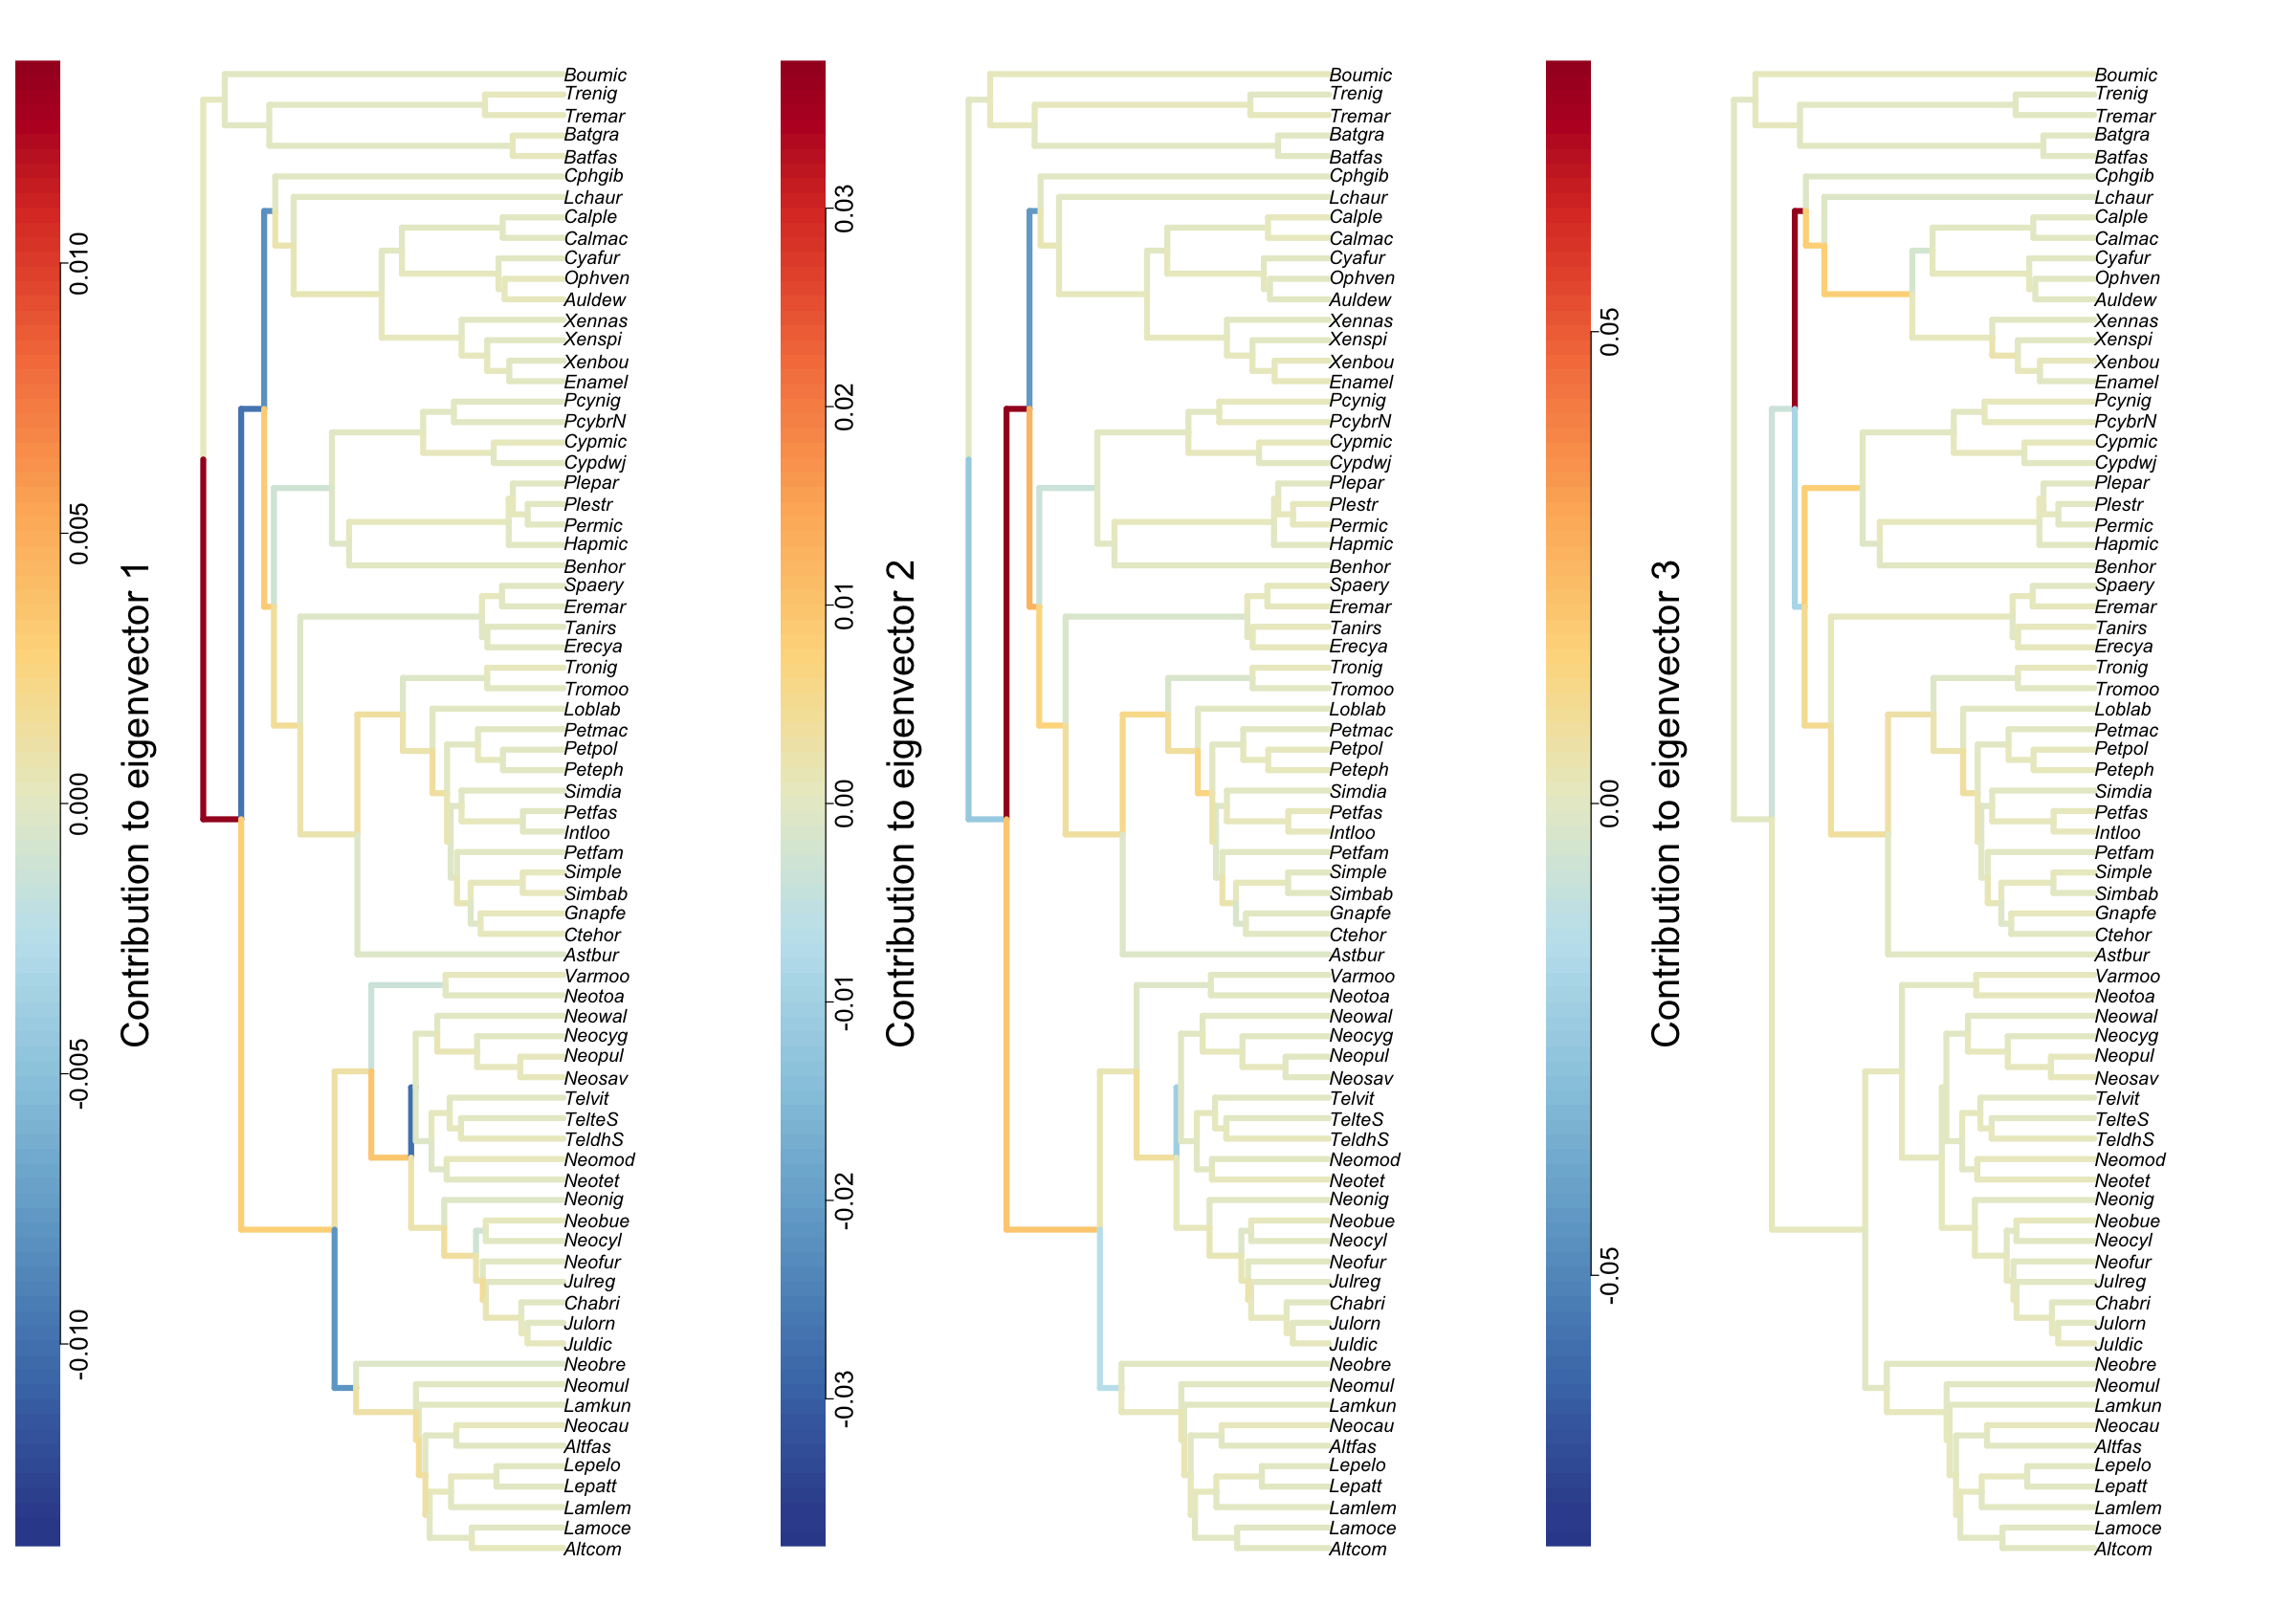

In [20]:
options(repr.plot.width = 20, repr.plot.height = 14)
layout(matrix(1:6, nrow = 1, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35))

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1, z = matrix(color_breaks_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 1", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_1, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2, z = matrix(color_breaks_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 2", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_2, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3, z = matrix(color_breaks_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 3", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_3, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

In [21]:
pdf("Figures_raw/chichlid_tree.pdf", width = 20, height = 14)

layout(matrix(1:6, nrow = 1, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35))

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1, z = matrix(color_breaks_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 1", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_1, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2, z = matrix(color_breaks_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 2", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_2, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3, z = matrix(color_breaks_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 3", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_3, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

dev.off()

pdf 
  2

In [22]:
svg("Figures_raw/chichlid_tree.svg", width = 20, height = 14)

layout(matrix(1:6, nrow = 1, byrow = TRUE), widths = c(3, 35, 3, 35, 3, 35))

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_1, z = matrix(color_breaks_1, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 1", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_1, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_2, z = matrix(color_breaks_2, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 2", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_2, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

par(mar = c(4, 1, 4, 0))
image(x = 1, y = color_breaks_3, z = matrix(color_breaks_3, nrow = 1),
      col = color_palette, axes = FALSE, xlab = "", ylab = "")
axis(4, cex.axis = 2)
mtext("Contribution to eigenvector 3", side = 4, line = 5, cex = 2)

par(mar = c(0, 8, 1, 0))
plot.phylo(cichlid_tree, edge.color = branch_colors_3, 
           edge.width = 5, show.tip.label = TRUE, cex = 1.5)

dev.off()

pdf 
  2

Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2 3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


TableGrob (1 x 1) "arrange": 1 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]

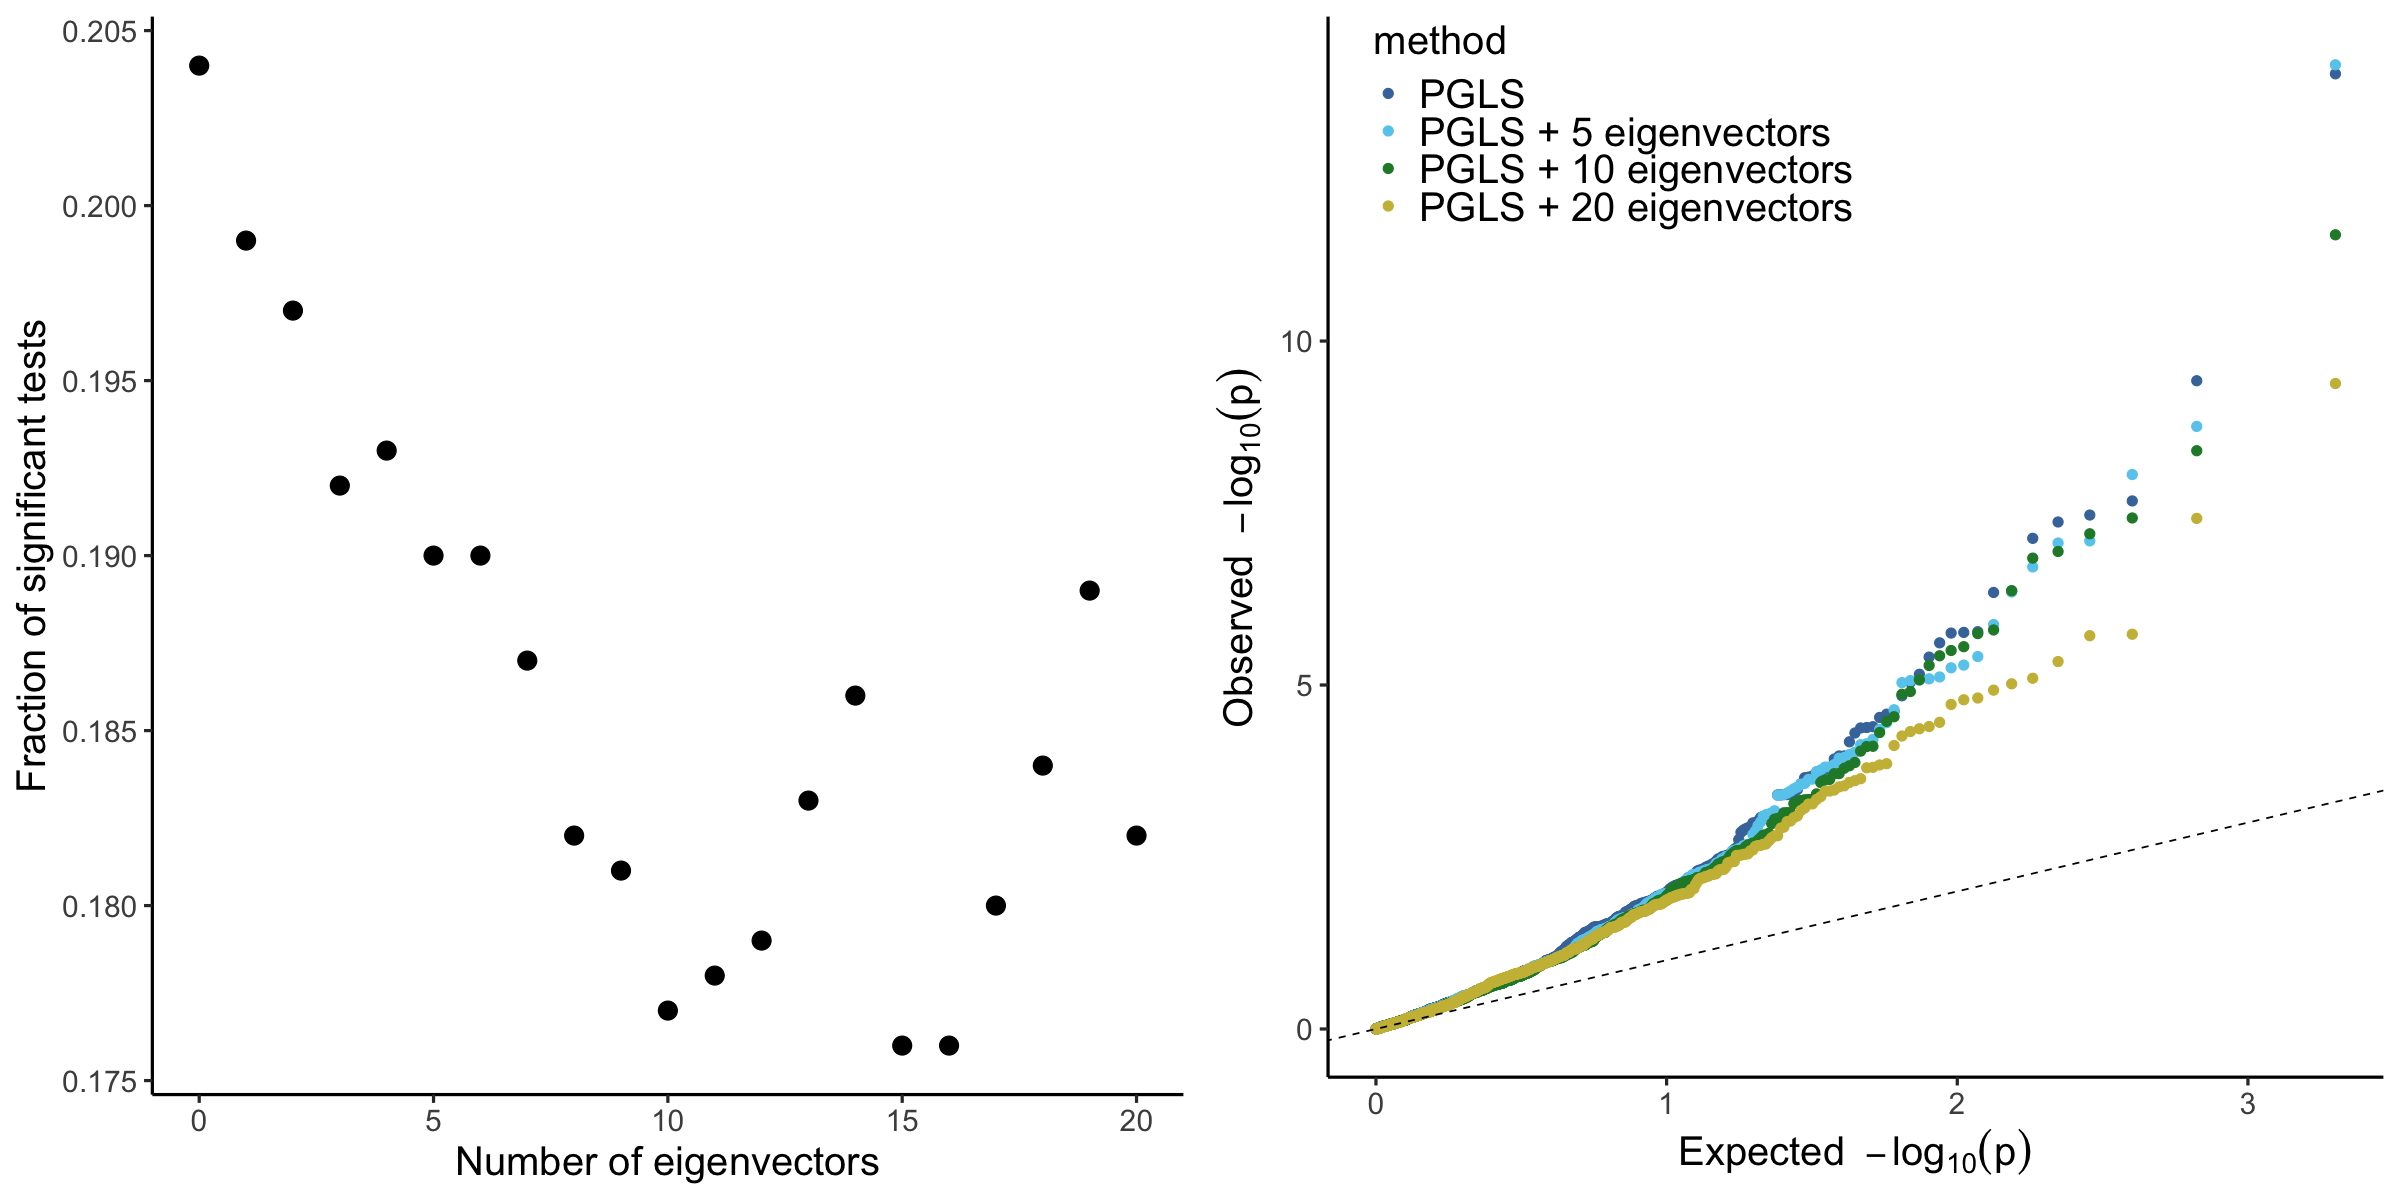

In [18]:
plot_pgls <- ggplot() +
  geom_point(data = p_vals_PC_summary, aes(PCs, FPR), size = 5) +
  theme_classic(base_size=20) +
  theme(axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") + 
  theme(legend.position=c(.22,.7),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24))

par(mar = c(1, 1, 1, 1))
qq_plot <- qq_plot_df %>% ggplot(aes(expected, observed, color = method)) +
  geom_point(size = 2.5) + 
  theme_classic(base_size=20) +
  xlab(expression(Expected~~-log[10](p))) +
  ylab(expression(Observed~~-log[10](p))) +
  theme(legend.position=c(.27,.9),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("PGLS", "PGLS + 5 eigenvectors", "PGLS + 10 eigenvectors", "PGLS + 20 eigenvectors")) + 
  geom_abline(slope = 1, intercept = 0,lty = 2)


options(repr.plot.width = 20, repr.plot.height = 10)

row <- arrangeGrob(plot_pgls, qq_plot, ncol = 2)

# Arrange all rows into one layout
g <- grid.arrange(row, nrow = 1)
g
ggsave("Figures_raw/chichlid_PGLS.pdf", g, width = 20, height = 10)
ggsave("Figures_raw/chichlid_PGLS.svg", g, width = 20, height = 10)